In [2]:
import pickle

import matplotlib.pyplot as plt
import networkx as nx

with open("networks/citation_data/pud_network.pkl", "rb") as f:
    G = pickle.load(f)

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

Nodes: 90, Edges: 160


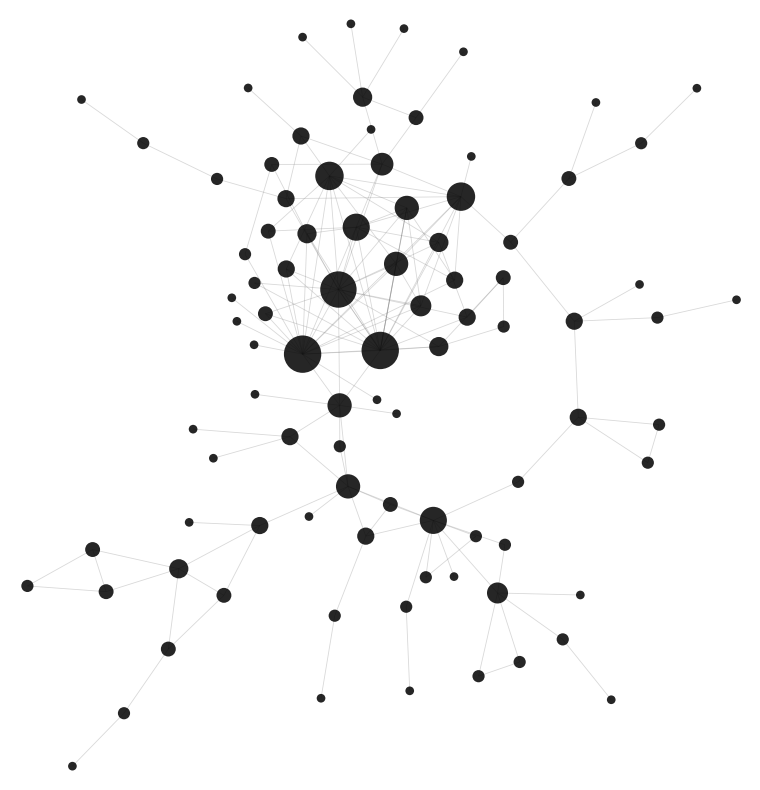

In [42]:
import numpy as np


def declutter_positions(pos, node_sizes, ax, nodelist, padding_pts=2.0, outer_iters=5, inner_iters=200):
    """Nudge node centers apart (in data space) until the drawn marker circles
    (sized in points^2, matching nx.draw_networkx_nodes' node_size) stop
    overlapping, given the actual pixel scale of `ax`. Nudges are local pairwise
    repulsions, so the overall cluster layout from `pos` is preserved. Returns the
    new positions together with each node's final radius in data units (useful for
    setting axis limits that don't clip the markers)."""
    xs = np.array([pos[n][0] for n in nodelist], dtype=float)
    ys = np.array([pos[n][1] for n in nodelist], dtype=float)
    radii_pts = np.sqrt(np.array(node_sizes, dtype=float) / np.pi)
    radii_data = None

    for _ in range(outer_iters):
        margin = 0.15
        xr = max(xs.max() - xs.min(), 1e-6)
        yr = max(ys.max() - ys.min(), 1e-6)
        ax.set_xlim(xs.min() - margin * xr, xs.max() + margin * xr)
        ax.set_ylim(ys.min() - margin * yr, ys.max() + margin * yr)
        ax.figure.canvas.draw()

        p0 = ax.transData.transform((0, 0))
        p1 = ax.transData.transform((1, 0))
        pixels_per_data_unit = np.hypot(*(p1 - p0))
        pixels_per_point = ax.figure.dpi / 72.0
        radii_data = (radii_pts + padding_pts) * pixels_per_point / pixels_per_data_unit

        for _ in range(inner_iters):
            dx = xs[:, None] - xs[None, :]
            dy = ys[:, None] - ys[None, :]
            dist = np.hypot(dx, dy)
            np.fill_diagonal(dist, np.inf)
            min_dist = radii_data[:, None] + radii_data[None, :]
            overlap = np.maximum(min_dist - dist, 0)
            if not np.any(overlap > 1e-9):
                break
            safe_dist = np.where(np.isinf(dist), 1.0, dist)
            ux, uy = dx / safe_dist, dy / safe_dist
            xs += (ux * overlap).sum(axis=1) * 0.25
            ys += (uy * overlap).sum(axis=1) * 0.25

    return {n: (xs[i], ys[i]) for i, n in enumerate(nodelist)}, radii_data


def draw_pud_network(G, ax, node_size_base=5, node_size_scale=50):
    """Kamada-Kawai layout (clusters connected nodes) + overlap-free node sizes,
    drawn into `ax`. Returns the final positions."""
    pos = nx.kamada_kawai_layout(G.to_undirected())
    degrees = dict(G.degree())
    node_sizes = [node_size_base + degrees[n] * node_size_scale for n in G.nodes()]
    nodelist = list(G.nodes())

    ax.set_aspect("equal", adjustable="box")
    pos, radii_data = declutter_positions(pos, node_sizes, ax, nodelist)

    nx.draw_networkx_edges(
        G, pos, ax=ax, edge_color="gray", alpha=0.3, width=0.6, arrows=False
    )
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        nodelist=nodelist,
        node_size=node_sizes,
        node_color="black",
        alpha=0.85,
        linewidths=0,
    )

    xs_final = np.array([pos[n][0] for n in nodelist])
    ys_final = np.array([pos[n][1] for n in nodelist])
    pad = radii_data * 1.15
    ax.set_xlim((xs_final - pad).min(), (xs_final + pad).max())
    ax.set_ylim((ys_final - pad).min(), (ys_final + pad).max())
    ax.axis("off")
    return pos


# Calibrate the PUD node-size scale so its largest (max-degree) node is exactly
# twice the diameter -- i.e. 4x the area, since node_size is an area -- of a
# node in the complete (K10) network, which uses base=5, scale=50 (see the
# simple-networks cell below).
_simple_base, _simple_scale = 1, 20
_complete_ref_size = _simple_base + (10 - 1) * _simple_scale  # every K10 node has degree 9

_pud_max_degree = max(dict(G.degree()).values())
_pud_node_size_scale = (4 * _complete_ref_size - _simple_base) / _pud_max_degree

fig, ax = plt.subplots(figsize=(10, 8))
draw_pud_network(G, ax, node_size_base=_simple_base, node_size_scale=_pud_node_size_scale)
plt.tight_layout()
plt.savefig("results/pud_network_black.png", dpi=300, bbox_inches="tight")
plt.show()

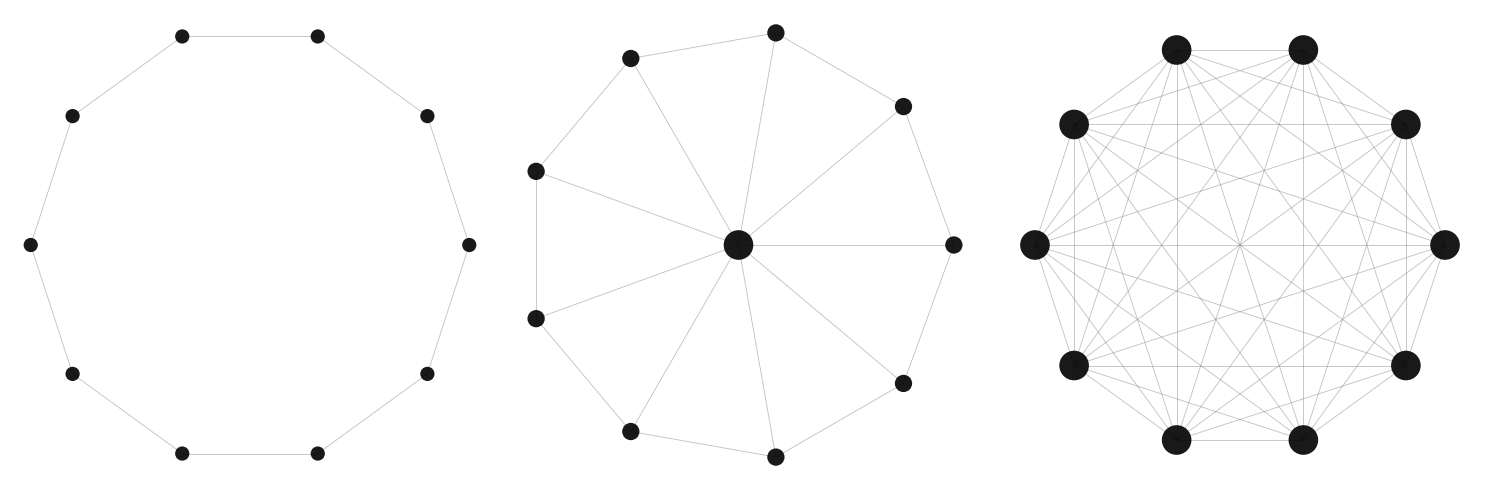

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

networks = {
    "Cycle": nx.cycle_graph(10),
    "Wheel": nx.wheel_graph(10),
    "Complete": nx.complete_graph(10),
}

for ax, (title, Gn) in zip(axes, networks.items()):
    if title == "Wheel":
        hub = 0
        pos = nx.circular_layout(Gn.subgraph([n for n in Gn if n != hub]))
        pos[hub] = (0.0, 0.0)
    else:
        pos = nx.circular_layout(Gn)

    ax.set_aspect("equal", adjustable="box")
    degrees = dict(Gn.degree())
    nodelist = list(Gn.nodes())
    node_sizes = [5 + degrees[n] * 50 for n in nodelist]
    pos, radii_data = declutter_positions(pos, node_sizes, ax, nodelist)

    nx.draw_networkx_edges(Gn, pos, ax=ax, edge_color="gray", alpha=0.5, width=0.6)
    nx.draw_networkx_nodes(
        Gn, pos, ax=ax, nodelist=nodelist, node_size=node_sizes,
        node_color="black", alpha=0.9, linewidths=0,
    )

    xs_final = np.array([pos[n][0] for n in nodelist])
    ys_final = np.array([pos[n][1] for n in nodelist])
    pad = radii_data * 1.15
    ax.set_xlim((xs_final - pad).min(), (xs_final + pad).max())
    ax.set_ylim((ys_final - pad).min(), (ys_final + pad).max())
    ax.axis("off")

plt.tight_layout()
plt.savefig("results/simple_networks_circular.png", dpi=300, bbox_inches="tight")
plt.show()

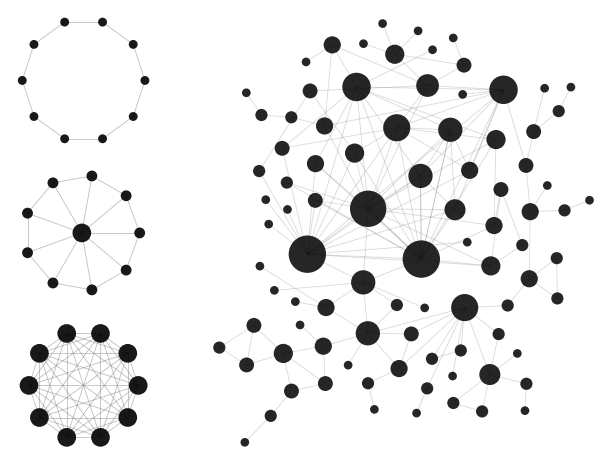

In [44]:
# A4 page with 1-inch margins -> printable width in inches. Height is derived
# from content instead of being forced to fill the whole page.
#
# The PUD network is drawn natively here (not embedded as a saved image):
# node_size is a physical (points^2) unit, so embedding a pre-rendered raster
# and letting imshow rescale it to fit a smaller panel would silently shrink
# the markers too, breaking the size calibration from the cell above.
page_width = 8.27
margin = 1.0
total_width = page_width - 2 * margin
gap = 0.2

r_pud_guess = 1.0  # kamada-kawai layouts of this graph render close to square
left_w = (total_width - gap) / (1 + 3 * r_pud_guess)
right_w = total_width - gap - left_w
fig_height = 3 * left_w

fig = plt.figure(figsize=(total_width, fig_height))
gs = fig.add_gridspec(3, 2, width_ratios=[left_w, right_w], wspace=0.08, hspace=0.08)

for i, (title, Gn) in enumerate(networks.items()):
    ax = fig.add_subplot(gs[i, 0])
    if title == "Wheel":
        hub = 0
        pos = nx.circular_layout(Gn.subgraph([n for n in Gn if n != hub]))
        pos[hub] = (0.0, 0.0)
    else:
        pos = nx.circular_layout(Gn)

    ax.set_aspect("equal", adjustable="box")
    degrees = dict(Gn.degree())
    nodelist = list(Gn.nodes())
    node_sizes = [_simple_base + degrees[n] * _simple_scale for n in nodelist]
    pos, radii_data = declutter_positions(pos, node_sizes, ax, nodelist)

    nx.draw_networkx_edges(Gn, pos, ax=ax, edge_color="gray", alpha=0.5, width=0.6)
    nx.draw_networkx_nodes(
        Gn, pos, ax=ax, nodelist=nodelist, node_size=node_sizes,
        node_color="black", alpha=0.9, linewidths=0,
    )

    xs_final = np.array([pos[n][0] for n in nodelist])
    ys_final = np.array([pos[n][1] for n in nodelist])
    pad = radii_data * 1.15
    ax.set_xlim((xs_final - pad).min(), (xs_final + pad).max())
    ax.set_ylim((ys_final - pad).min(), (ys_final + pad).max())
    ax.axis("off")

ax_pud = fig.add_subplot(gs[:, 1])
draw_pud_network(G, ax_pud, node_size_base=_simple_base, node_size_scale=_pud_node_size_scale)

fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01, wspace=0.08, hspace=0.08)
plt.savefig("results/figure_article.png", dpi=300)
plt.show()